# Personal Information
Name: **Jesper Kooijman**

StudentID: **14237318**

Email: **jesper.kooijman@student.uva.nl**

Submitted on: **16.03.2026**

Github: https://github.com/Jesperk88/Thesis_masters

# Data Context

This thesis will primarily use the Qilin dataset, containing real-world search logs from the social media platform Xiaohongshu that displays a two-column content layout. The data includes primarily queries, ranked results, and click signals. For this study the we will use the search_test and search_train splits as well as the DQA split available on HuggingFace and develop them into standard search sessions and those where a DQA module was displayed. This will enable us to compare user interaction across the different layouts. 

Additionally, a subset of the Avazu dataset is included as our external benchmark. It consist of mobile advertising impression data woth click labels. It is widely used in CTR prediction research. It will serve as a reference dataset to validate the baseline modeling pipeline in another domain than search queries.

# Data Description

##### Data transformation and class balance

The Qilin logs are stored as a nested format at the session level and since click models are trained at the impression level, the data was transformed that each row represented a single displayed item with its rank and click signal. The session where DQA had an output of '-1' were treated as a standard session. For user behaviour analysis, the search test, search train, and non-DQA DQA session were concatenated.

After this preliminary transformation, the dataset contained over a million standard impressions and roughly 27,000 DQA impressions. The overall CTR was about 21% in both subsets where the two-proportion Z-test did not indicate statistical significance in the difference between the CTR of DQA and non-DQA sessions (p = 0.237). This suggests that any layout difference will be more apparent at a granular level.

##### Distributions and layout effect

THe standard session length were right skewed with with a median of 1 but a mean of 1.73 whilst the DQA sessions had a median of 1 as well as a mean of 1.01, suggesting almost no skewness. It is also suggested that for DQA sessions, almost all questions were satiated with the first search whereas for standard sessions, a multi-search session was necessary. 

The CTR shows a consistent decrease with increasing rank positions. This indicated vertical position bias. Additionally, left-sided items show a slightly higher CTR of ~22% compared to right column items of ~19-20%, supporting the inclusion of a rank and column indicator variable in the predictive model. 

##### Baseline modeling and external validation

For the baseline, a Logistic Regression model was trained using the position and layout-related feature on the predefined train and test split for the standard sessions and on the train-test split of the DQA sessions. The models got an ROC-AUC of 0.6065 and a Logloss of 0.5188 and ROC-AUC of 0.6164 and LogLoss of 0.4923 on the test sets for standard and DQA sessions respectively. These performances are modest but serve as a reference point for subsequent models.

When applying the same baseline to the external Avazu dataset, the model achieves an AUC of 0.5182 and LogLoss of 0.4654. The CTR was 17.49%. For this dataset, the CTR spikes at position 5. This is due to the position corresponding to ad placements and does not follow the same sequential ranking as Qilin does, illustrating that positional signal are context dependent.

### Importing Libraries

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from statsmodels.stats.proportion import proportions_ztest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import train_test_split

### Data Loading

In [2]:
from datasets import load_dataset

# Load datasets
DQA = load_dataset("THUIR/Qilin", "dqa")
Search_test = load_dataset("THUIR/Qilin", "search_test")
Search_train = load_dataset("THUIR/Qilin", "search_train")

dqa = DQA['train'].to_pandas()
search_train = Search_train['train'].to_pandas()
search_test = Search_test['train'].to_pandas()

c:\Users\kooij\Desktop\DS_Master\Thesis\Thesis_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data overview



In [3]:
# Initial inspection
print("Raw Dataset Shapes")
print(f"Search Train: {search_train.shape}")
print(f"Search Test: {search_test.shape}")
print(f"DQA: {dqa.shape}\n")

print("Dataset Features")
print(f"dqa: {list(dqa.columns)}")
print(f"search_train: {list(search_train.columns)}")
print(f"search_test: {list(search_test.columns)}")


Raw Dataset Shapes
Search Train: (44024, 8)
Search Test: (6192, 10)
DQA: (6972, 15)

Dataset Features
dqa: ['query', 'query_from_type', 'dqa_output', 'is_like_clk', 'is_onebox_trace_clk', 'is_content_clk', 'is_experience_clk', 'recent_clicked_note_idxs', 'ref_note_idx_list', 'session_idx', 'search_idx', 'user_idx', 'bm25_results', 'dpr_results', 'search_result_details_with_idx']
search_train: ['query', 'query_from_type', 'recent_clicked_note_idxs', 'search_idx', 'session_idx', 'user_idx', 'dpr_results', 'search_result_details_with_idx']
search_test: ['query', 'query_from_type', 'recent_clicked_note_idxs', 'search_idx', 'session_idx', 'user_idx', 'bm25_results', 'dpr_results', 'search_results', 'search_result_details_with_idx']


### Data Cleaning

We filter the DQA subset on '-1' to find actual searches that led to a DQA output and those that did not. Those that did not function as standard searches and are therefore concatenated to the baseline dataset along with search train and search test. This large dataset will be used for the 2 subquestion that analyse user behaviour. For subquestion 3, we will not train the model on the search test set as this would be data leakage.

In [4]:
# Filter the DQA dataset based on the -1 indicator in the 'dqa_output' column
dqa_valid = dqa[dqa['dqa_output'] != '-1'].copy()
dqa_failed = dqa[dqa['dqa_output'] == '-1'].copy()

print("DQA Split Results")
print(f"Valid DQA Sessions: {len(dqa_valid)}")
print(f"Failed DQA Sessions: {len(dqa_failed)}\n")

# The robust baseline dataset
# I merge the training data, test data, and the failed DQA sessions
standard_baseline = pd.concat([search_train, search_test, dqa_failed], ignore_index=True)

print("Final Analysis Datasets")
print(f"Standard Two-Column Baseline Shape: {standard_baseline.shape}")
print(f"DQA-Present Dataset Shape: {dqa_valid.shape}")

DQA Split Results
Valid DQA Sessions: 2932
Failed DQA Sessions: 4040

Final Analysis Datasets
Standard Two-Column Baseline Shape: (54256, 16)
DQA-Present Dataset Shape: (2932, 15)


In [5]:
print(standard_baseline.columns)
print(dqa_valid.columns)

Index(['query', 'query_from_type', 'recent_clicked_note_idxs', 'search_idx',
       'session_idx', 'user_idx', 'dpr_results',
       'search_result_details_with_idx', 'bm25_results', 'search_results',
       'dqa_output', 'is_like_clk', 'is_onebox_trace_clk', 'is_content_clk',
       'is_experience_clk', 'ref_note_idx_list'],
      dtype='str')
Index(['query', 'query_from_type', 'dqa_output', 'is_like_clk',
       'is_onebox_trace_clk', 'is_content_clk', 'is_experience_clk',
       'recent_clicked_note_idxs', 'ref_note_idx_list', 'session_idx',
       'search_idx', 'user_idx', 'bm25_results', 'dpr_results',
       'search_result_details_with_idx'],
      dtype='str')


### Analysis 1: Session length and engagement

This section explores how many searches there are per session in both the DQA-present and standard traffic. This helps study user behaviour before transforming the data to impression level and provides insight into how the DQA sessions differ. 

Searches per Session
Baseline -  Mean: 1.73, Median: 1.0
DQA      -  Mean: 1.01, Median: 1.0

Single Search Result Entry
{'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 1684016, 'page_time': nan, 'position': 5.0, 'search_timestamp': 1732138228.0, 'share': 0.0}


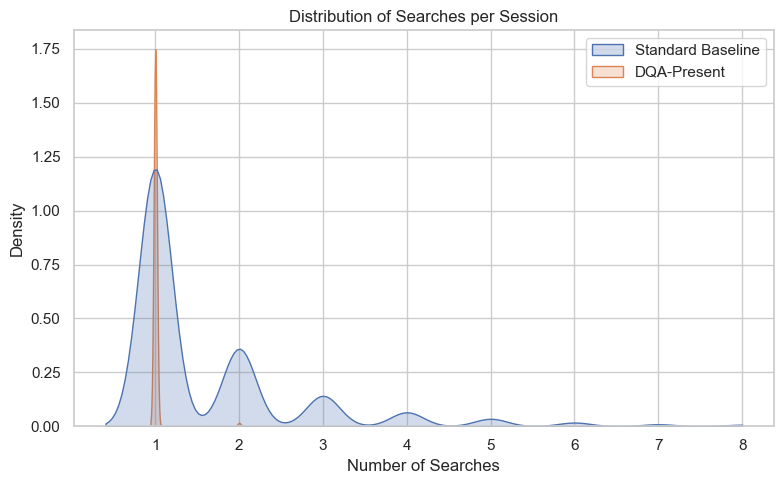

In [6]:
sns.set_theme(style="whitegrid")

# Calculate the number of searches per session for both datasets
base_lengths = standard_baseline.groupby('session_idx').size()
dqa_lengths = dqa_valid.groupby('session_idx').size()

print("Searches per Session")
print(f"Baseline -  Mean: {base_lengths.mean():.2f}, Median: {base_lengths.median()}")
print(f"DQA      -  Mean: {dqa_lengths.mean():.2f}, Median: {dqa_lengths.median()}\n")

# Inspect Single Entry 
print("Single Search Result Entry")
print(standard_baseline['search_result_details_with_idx'].iloc[0][0])

# Plotting
plt.figure(figsize=(8, 5))

sns.kdeplot(data={'Standard Baseline': base_lengths, 'DQA-Present': dqa_lengths}, 
            fill=True, palette=['#4C72B0', '#DD8452'], clip=(0, 8))
plt.title('Distribution of Searches per Session')
plt.xlabel('Number of Searches')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Most sessions in either subset is of a single search with median = 1. The traffic in the standard sessions shows a longer tail of multi-search sessions. This is noticed in the visualisation as well as the mean of 1.73 as opposed to the mean of the DQA sessions of 1.01. DQA session appear to be shorter, although we cannot determine yet if this reflects faster answering or differences in query type. 

### Analysis 2: Impression-level transformation and class balance

Click through models operate at the impression level, so the nested logs are transformed into individual impressions of items. An impression refers to a single item displayed to the user at a specific position during a search. After this, the CTR is calculated for both subsets to show class imbalance, ensuring if the data sligns with our modeling approach.

In [7]:
def flatten_impressions(df, col='search_result_details_with_idx'):
    # Explode lists into rows and drop missing values
    exp = df.dropna(subset=[col]).explode(col).reset_index(drop=True)
    # Expand dicts into columns and merge with session/search IDs in one go
    return exp[['session_idx', 'search_idx']].join(pd.json_normalize(exp[col]))

# Flatten the impressions for both datasets
base_imp = flatten_impressions(standard_baseline)

# Filter out top-level insertions (Position 0) to strictly isolate the two-column grid
base_imp = base_imp[base_imp['position'] > 0]

dqa_imp = flatten_impressions(dqa_valid)

# Print shapes and CTR together for a cleaner output
print(f"Baseline Impressions: {base_imp.shape}, Overall CTR: {base_imp['click'].mean()*100:.3f}%")
print(f"DQA Impressions:      {dqa_imp.shape}, Overall CTR: {dqa_imp['click'].mean()*100:.3f}%")

Baseline Impressions: (1029300, 11), Overall CTR: 21.023%
DQA Impressions:      (27656, 11), Overall CTR: 20.726%


After flattening the nested logs, the dataset is expanded to over a million impressions for the standard sessions and roughly 28,000 DQA impressions. The overall CTR is similar at about 21%, indicating that the distribution is stable across layouts. For later modeling, this will suggest that performance differences are unlikely to be drived purely by changes in class balance. 

### Analysis 3: Comparing overall click rates

Evaluating how clicking behaviour differs between DQA and non-DQA sessions is done by aggregating CTRs. The null hypothesis here assumes that the CTR is identical for DQA-present and non_DQA sessions. A two-proportion Z-test is used to assess whether any difference is statistically significant. This will provide an initial assessment of the variation of layout related behaviour.

In [8]:
print("Statistical significance test (Two-proportion Z-Test)")

# Number of clicks (successes)
clicks_base = base_imp['click'].sum()
clicks_dqa = dqa_imp['click'].sum()

# Total number of impressions (trials)
nobs_base = len(base_imp)
nobs_dqa = len(dqa_imp)

# Run the Z-test
stat, pval = proportions_ztest([clicks_dqa, clicks_base], [nobs_dqa, nobs_base])

print(f"Z-statistic: {stat:.4f}")
print(f"P-value:     {pval:.4e}")

if pval < 0.05:
    print("Conclusion: The difference in CTR between DQA-present and standard Baseline is statistically significant.")
else:
    print("Conclusion: The difference in CTR is not statistically significant.")

Statistical significance test (Two-proportion Z-Test)
Z-statistic: -1.1958
P-value:     2.3177e-01
Conclusion: The difference in CTR is not statistically significant.


The two-proportion Z-test does not yield a statistically significant difference in the overall CTR between non-DQA and DQA sessions at an aggregated level, implying that if there were to be any layout effect, it would likely be at a more granular level. 

### Analysis 4: Position and column effects

This section examines CTRs across the different ranking positions as well as the left versus right column in this two-column layout. Plotting the CTR and comparing left versus right column interaction is done to assess potential biases in this layout. 

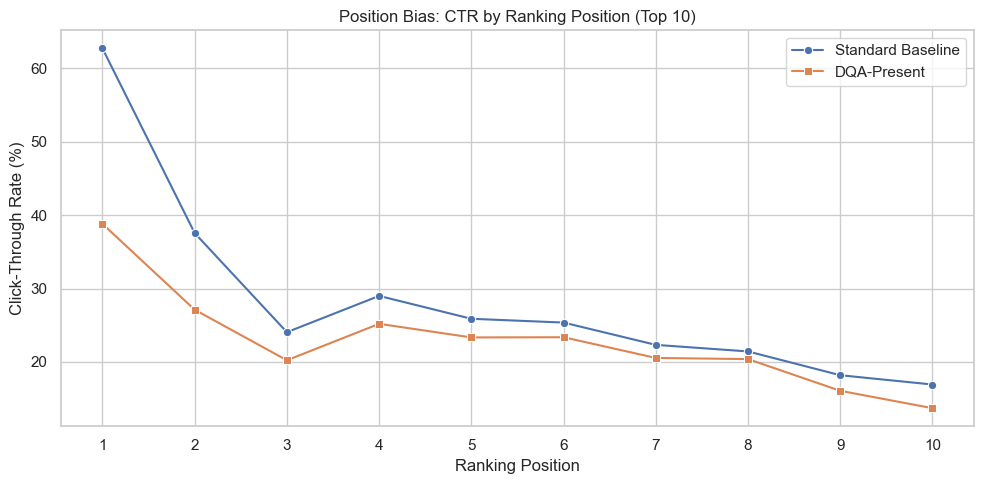

Two-Column Layout: CTR by side
Standard Baseline - Left Column CTR: 22.13%, Right Column CTR: 19.88%
DQA-Present       - Left Column CTR: 21.77%, Right Column CTR: 19.64%



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by position and calculate the mean click rate (percentage)
base_pos_ctr = base_imp.groupby('position')['click'].mean() * 100
dqa_pos_ctr = dqa_imp.groupby('position')['click'].mean() * 100

# Limit to top 10 positions for a clean visual
base_pos_ctr = base_pos_ctr[base_pos_ctr.index <= 10]
dqa_pos_ctr = dqa_pos_ctr[dqa_pos_ctr.index <= 10]

plt.figure(figsize=(10, 5))

sns.lineplot(x=base_pos_ctr.index, y=base_pos_ctr.values, marker='o', label='Standard Baseline', color='#4C72B0')
sns.lineplot(x=dqa_pos_ctr.index, y=dqa_pos_ctr.values, marker='s', label='DQA-Present', color='#DD8452')
plt.title('Position Bias: CTR by Ranking Position (Top 10)')
plt.xlabel('Ranking Position')
plt.ylabel('Click-Through Rate (%)')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

# Create a new column to identify left vs right column based on position
base_imp['is_left_column'] = base_imp['position'] % 2 != 0
dqa_imp['is_left_column'] = dqa_imp['position'] % 2 != 0

print("Two-Column Layout: CTR by side")
base_left_ctr = base_imp[base_imp['is_left_column']]['click'].mean() * 100
base_right_ctr = base_imp[~base_imp['is_left_column']]['click'].mean() * 100
dqa_left_ctr = dqa_imp[dqa_imp['is_left_column']]['click'].mean() * 100
dqa_right_ctr = dqa_imp[~dqa_imp['is_left_column']]['click'].mean() * 100

print(f"Standard Baseline - Left Column CTR: {base_left_ctr:.2f}%, Right Column CTR: {base_right_ctr:.2f}%")
print(f"DQA-Present       - Left Column CTR: {dqa_left_ctr:.2f}%, Right Column CTR: {dqa_right_ctr:.2f}%\n")

As corroborated by the related works section where the examination bias follows a certain pattern, here, as ranking position increases, CTR decreases. This indicated the presence of vertical position bias where users are more likely to view and interact with higher appearing items. Additionally, the left column shows a higher CTR than the right column in both subsets at ~22% and ~20% respectively. This hints that the horizontal placement of an item may influence interaction probability and also supports adding this as a feature to the predictive model. 

### Micro-Analysis for SQ1

,Position,Base_CTR,DQA_CTR,Diff (Base-DQA),p_value,Cohen_h,Significant (p<0.05)
0,1,0.6269,0.3880,0.2389,0.0000,0.4825,True
1,2,0.3754,0.2711,0.1043,0.0000,0.2237,True
2,3,0.2405,0.2023,0.0383,0.0000,0.0922,True
3,4,0.2899,0.2519,0.0380,0.0002,0.0856,True
4,5,0.2588,0.2334,0.0254,0.0320,0.0590,True
5,6,0.2536,0.2336,0.0200,0.1057,0.0465,False
6,7,0.2233,0.2054,0.0178,0.1688,0.0434,False
7,8,0.2143,0.2039,0.0104,0.4220,0.0256,False
8,9,0.1819,0.1607,0.0212,0.1102,0.0564,False
9,10,0.1693,0.1370,0.0322,0.0128,0.0896,True


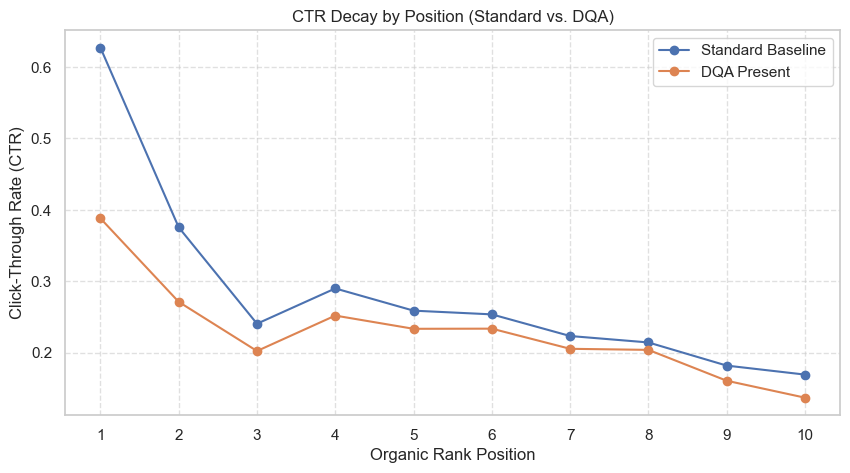

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

# Set max position to analyze (Top 10 is standard for SERP analysis)
MAX_POS = 10
results = []

for pos in range(1, MAX_POS + 1):
    base_pos = base_imp[base_imp['position'] == pos]
    dqa_pos = dqa_imp[dqa_imp['position'] == pos]
    
    if len(base_pos) == 0 or len(dqa_pos) == 0:
        continue
        
    # Get click counts and totals
    clicks_base, nobs_base = base_pos['click'].sum(), len(base_pos)
    clicks_dqa, nobs_dqa = dqa_pos['click'].sum(), len(dqa_pos)
    
    # Calculate CTR
    p_base = clicks_base / nobs_base if nobs_base > 0 else 0
    p_dqa = clicks_dqa / nobs_dqa if nobs_dqa > 0 else 0
    
    # Run Two-Proportion Z-Test
    counts = np.array([clicks_base, clicks_dqa])
    nobs = np.array([nobs_base, nobs_dqa])
    stat, pval = proportions_ztest(counts, nobs)
    
    # Calculate Cohen's h (Effect Size)
    h = 2 * (np.arcsin(np.sqrt(p_base)) - np.arcsin(np.sqrt(p_dqa)))
    
    results.append({
        'Position': pos,
        'Base_CTR': round(p_base, 4),
        'DQA_CTR': round(p_dqa, 4),
        'Diff (Base-DQA)': round(p_base - p_dqa, 4),
        'p_value': round(pval, 4),
        'Cohen_h': round(h, 4),
        'Significant (p<0.05)': pval < 0.05
    })

pos_stats_df = pd.DataFrame(results)
display(pos_stats_df)

# Plotting the CTR decay
plt.figure(figsize=(10, 5))
plt.plot(pos_stats_df['Position'], pos_stats_df['Base_CTR'], marker='o', label='Standard Baseline')
plt.plot(pos_stats_df['Position'], pos_stats_df['DQA_CTR'], marker='o', label='DQA Present')
plt.title('CTR Decay by Position (Standard vs. DQA)')
plt.xlabel('Organic Rank Position')
plt.ylabel('Click-Through Rate (CTR)')
plt.xticks(range(1, MAX_POS + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

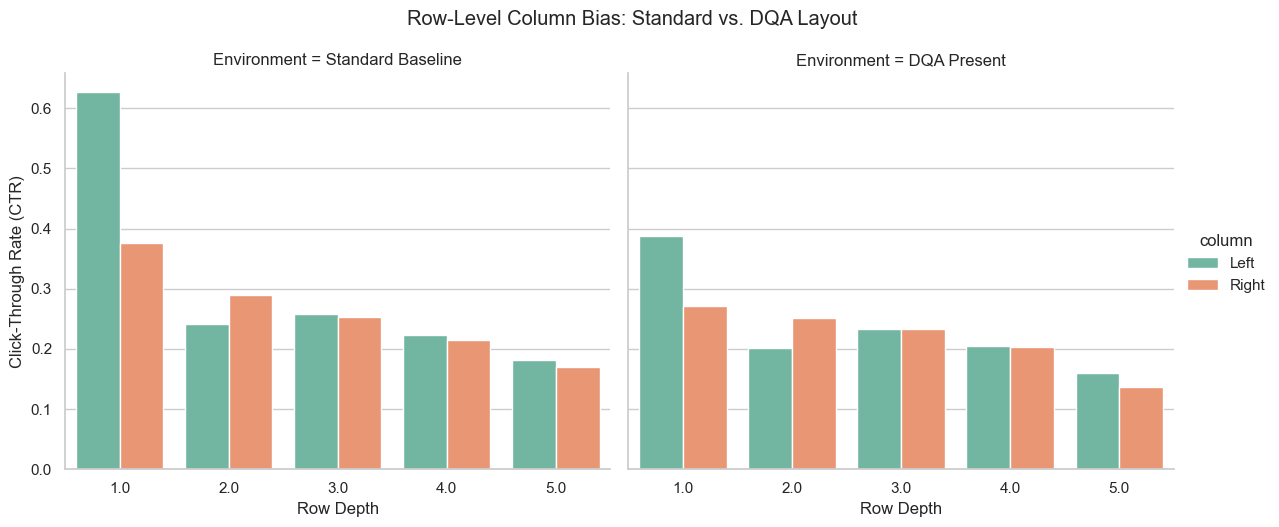

In [ ]:
# Helper function to map 1D position to 2D row/column layout
def assign_layout(df):
    df_mapped = df.copy()
    df_mapped['row'] = (df_mapped['position'] + 1) // 2
    df_mapped['column'] = np.where(df_mapped['position'] % 2 != 0, 'Left', 'Right')
    return df_mapped

# Map top 10 positions (First 5 Rows)
base_layout = assign_layout(base_imp[base_imp['position'] <= 10])
dqa_layout = assign_layout(dqa_imp[dqa_imp['position'] <= 10])

# Aggregate CTR by Row and Column
base_row_ctr = base_layout.groupby(['row', 'column'])['click'].mean().reset_index()
base_row_ctr['Environment'] = 'Standard Baseline'

dqa_row_ctr = dqa_layout.groupby(['row', 'column'])['click'].mean().reset_index()
dqa_row_ctr['Environment'] = 'DQA Present'

layout_ctr = pd.concat([base_row_ctr, dqa_row_ctr])

# Plot the layout interaction using Seaborn FacetGrid
g = sns.catplot(
    data=layout_ctr, kind="bar",
    x="row", y="click", hue="column", col="Environment",
    palette="Set2", height=5, aspect=1.2
)
g.set_axis_labels("Row Depth", "Click-Through Rate (CTR)")
g.fig.suptitle('Row-Level Column Bias: Standard vs. DQA Layout', y=1.05)
plt.show()

### Analysis 5: Baseline Logistic Regression model

For our predictive baseline, a simple Logistic Regression model is trained using position rank and a dummy variable which represents left vs. right column as features in order to predict clicks. Logistic regression is often used as a baseline for CTR as it can model the probability of a click as a function of rank while being interpretable and efficient. This model is trained solely on the training subset, and then evaluated using ROC-AUC and LogLoss on the predefined test split of the Qilin dataset. The results of this analysis will be a reference for later modeling. 

In [13]:
### Baseline model for standard sessions

# Flatten to impression level
train_imp = flatten_impressions(search_train)
test_imp = flatten_impressions(search_test)

# Add the two-column logic feature
train_imp['is_left_column'] = train_imp['position'] % 2 != 0
test_imp['is_left_column'] = test_imp['position'] % 2 != 0

# Define features (X) and target (y)
X_train = train_imp[['position', 'is_left_column']].fillna(0)
y_train = train_imp['click'].fillna(0)

X_test = test_imp[['position', 'is_left_column']].fillna(0)
y_test = test_imp['click'].fillna(0)

print(f"Training on {len(X_train)} impressions, Testing on {len(X_test)} impressions.")

# Initialize and train the Logistic Regression baseline
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict probabilities and evaluate on the test set
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_prob)
loss = log_loss(y_test, y_pred_prob)

print("Baseline Model Performance")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Log Loss:      {loss:.4f}")

Training on 841675 impressions, Testing on 128191 impressions.
Baseline Model Performance
ROC-AUC Score: 0.6065
Log Loss:      0.5188


We will also train and test the baseline model on DQA sessions. Because this subset contains fewer impressions than standard searches, the resulting performance estimates may show greater variance. 

In [14]:
### Baseline model for DQA sessions

# Flatten to impression level
dqa_imp = flatten_impressions(dqa_valid)

# Add the two-column logic feature
dqa_imp['is_left_column'] = dqa_imp['position'] % 2 != 0

# Define features and target
X = dqa_imp[['position', 'is_left_column']].fillna(0)
y = dqa_imp['click'].fillna(0)

print(f"Total DQA impressions: {len(X)}")

### Train-test split (stratified to preserve class balance)
X_train_dqa, X_test_dqa, y_train_dqa, y_test_dqa = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train_dqa)} impressions, Testing on {len(X_test_dqa)} impressions.")

### Train Logistic Regression baseline
lr_model_dqa = LogisticRegression()
lr_model_dqa.fit(X_train_dqa, y_train_dqa)

### Evaluate
y_pred_prob_dqa = lr_model_dqa.predict_proba(X_test_dqa)[:, 1]

auc_score_dqa = roc_auc_score(y_test_dqa, y_pred_prob_dqa)
loss_dqa = log_loss(y_test_dqa, y_pred_prob_dqa)

print("DQA Baseline Model Performance")
print(f"ROC-AUC Score: {auc_score_dqa:.4f}")
print(f"Log Loss:      {loss_dqa:.4f}")

Total DQA impressions: 27656
Training on 22124 impressions, Testing on 5532 impressions.
DQA Baseline Model Performance
ROC-AUC Score: 0.6164
Log Loss:      0.4923


The baseline Logistic Regression model for the standard sessions achieves an ROC-AUC of 0.6065 and a LogLoss of 0.5188 using only the position and layout features. The DQA sessions model achieves an ROC-AUC of 0.6164 and LogLoss of 0.4923. These performances are modest but provides us with baselines for subsequent models. 

### Importing external dataset

In [15]:
# Getting the dataset
import kagglehub

path = kagglehub.dataset_download("wuyingwen06/avazu-ctr-train")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kooij\.cache\kagglehub\datasets\wuyingwen06\avazu-ctr-train\versions\1


### Analysis 6: External dataset validation

For our external benchmark, the same evaluation pipeline is used on a subset of the Avazu dataset, which is a large CTR prediction dataset containing 11 days of mobile advertisement impressions. Once again the class balance will be examined and the same baseline model will be run to ensure reproducability in different domains. However, it must be noted that Avazu can not be directly compared to Qilin due to the difference in domain and structue. It is used here as an external benchmark to validate our baseline model pipeline.

Loading Avazu Kaggle dataset...
Avazu Sample Shape: (100000, 24)
Avazu Baseline CTR: 17.49%


C:\Users\kooij\AppData\Local\Temp\ipykernel_8540\3892308497.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avazu_pos_ctr.index, y=avazu_pos_ctr.values, palette='viridis')


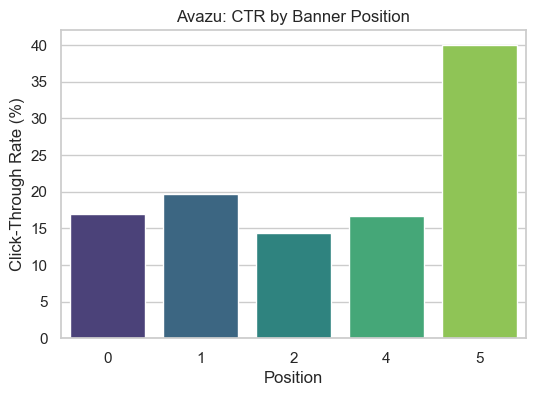


 Avazu External Baseline Performance
ROC-AUC Score: 0.5182
Log Loss:      0.4654


In [16]:
# We use nrows=100000 to get a solid sample without crashing the memory
print("Loading Avazu Kaggle dataset...")
avazu_path = path + "/train.csv" # kagglehub returns the folder path
avazu_df = pd.read_csv(avazu_path, nrows=100000)

# Class Balance (Overall CTR)
avazu_ctr = avazu_df['click'].mean() * 100
print(f"Avazu Sample Shape: {avazu_df.shape}")
print(f"Avazu Baseline CTR: {avazu_ctr:.2f}%")

avazu_pos_ctr = avazu_df.groupby('banner_pos')['click'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=avazu_pos_ctr.index, y=avazu_pos_ctr.values, palette='viridis')
plt.title('Avazu: CTR by Banner Position')
plt.ylabel('Click-Through Rate (%)')
plt.xlabel('Position')
plt.show()

# Using 'banner_pos' to predict 'click' to mirror the Qilin analysis
X_az = avazu_df[['banner_pos']].fillna(0)
y_az = avazu_df['click']

# Split and Train
X_train_az, X_test_az, y_train_az, y_test_az = train_test_split(X_az, y_az, test_size=0.2, random_state=42)

lr_az = LogisticRegression()
lr_az.fit(X_train_az, y_train_az)

# Final Evaluation Metrics
az_probs = lr_az.predict_proba(X_test_az)[:, 1]
print(f"\n Avazu External Baseline Performance")
print(f"ROC-AUC Score: {roc_auc_score(y_test_az, az_probs):.4f}")
print(f"Log Loss:      {log_loss(y_test_az, az_probs):.4f}")

On the Avazu dataset, the baseline CTR is ~17.5%. The Logistic regression achieves an AUC of 0.5182 and LogLoss of 0.4654, confirming that the pipeline works on an external dataset. What is most noticeable is that the position distribution of the CTRs spikes at position 5 at nearly 40%. Avazu's position identifiers represent difference advertisement placements which does not follow the same sequential ranking as the Qilin dataset. The spike likely reflects difference in ad formats rather than the rank-based behaviour seen in the Qilin data, highlighting that positional effects are context and dataset specific. 